In [3]:
from topological_insulator import Problem

In [4]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

In [5]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC, t_1, delta):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                # parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.2 * t_1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1 - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1 + delta
            except:
                pass
        # print(parser)   

In [6]:
location = "bulk"

In [7]:
Delta_SOC = -5
cases = {
    0: {"t_1": -1, "delta": 0.632},
    1: {"t_1": -1, "delta": 0.832}
}

In [ ]:
results = {}
for n, eigenvalue_dict in cases.items():
    t_1 = eigenvalue_dict["t_1"]
    delta = eigenvalue_dict["delta"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t_1}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, Delta_SOC, t_1, delta)
    problem.setup(
        N_r = 10,
        N_k = 40,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.632
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [9]:
j_3_2 = [8, 9, 10, 11, 12, 13, 14, 15]
bands = [12, 13, 14, 15]

## Case 0

In [10]:
g = results[0].geometry
tb_bulk = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[1.04719755 1.81379936]: delta = -1.0
k=[ 1.04719755 -1.81379936]: delta = 1.0
k=[2.0943951 0.       ]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 0


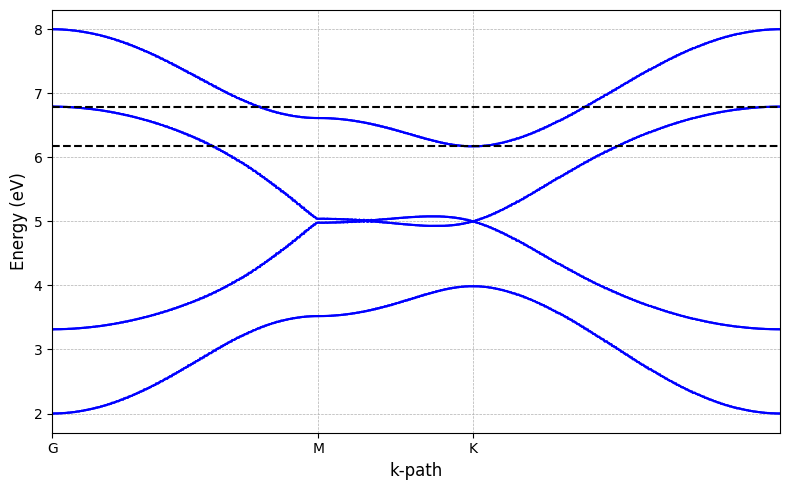

In [11]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_acceptor_band_gap(only_dE=False)
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])

## Case 1

In [12]:
g = results[1].geometry
tb_bulk = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[1.04719755 1.81379936]: delta = -1.0
k=[ 1.04719755 -1.81379936]: delta = -1.0
k=[2.0943951 0.       ]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 1
dE = 0.139 eV


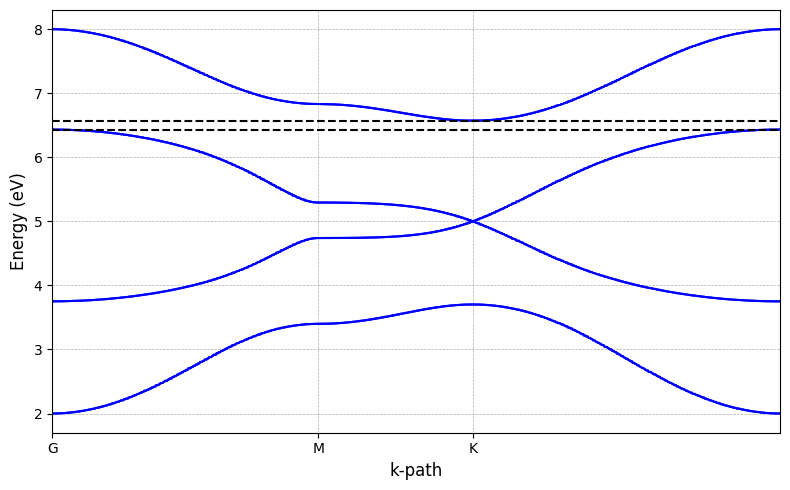

In [13]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_acceptor_band_gap(only_dE=False)
print(f"dE = {dE:.3f} eV")
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])


In [99]:
Psi_k_0 = tb_bulk.band_structure_data["eigenvector_dict"][15]
Psi_k_0[0]

array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        3.64931530e-18+0.00000000e+00j,  5.84027847e-17+3.69361651e-17j,
        5.85439912e-01-2.67068265e-01j, -1.66533454e-16+8.32667268e-17j,
        3.97251676e-16-2.22168239e-16j, -2.74950172e-01-1.01671306e-01j,
        6.66133815e-16-4.47558657e-16j, -2.11636264e-16+1.66533454e-16j,
       -7.47352099e-17+3.69256518e-17j,  7.34256567e-17-3.97621664e-17j,
       -5.85439912e-01+2.67068265e-01j,  2.36995162e-16-1.28640908e-16j,
       -2.88410050e-17+2.30519833e-16j,  2.74950172e-01+1.01671306e-01j])

In [100]:
data = tb_bulk.sublattice_data_dict
idx_A, idx_B = data["A"]["idx"], data["B"]["idx"]
r_A, r_B = g.sites[idx_A], g.sites[idx_B]    

In [ ]:
kx_bulk, ky_bulk = g.kx_bulk, g.ky_bulk
N_projections = len(tb_bulk.coupled_states)
slice_A = slice(0 * N_projections, (0 + 1) * N_projections)
slice_B = slice(1 * N_projections, (1 + 1) * N_projections)
Psi_r_0 = np.zeros(shape=Psi_k_0[0].shape, dtype=complex)
for k_idx, c_k_i in enumerate(Psi_k_0):
    k = np.array(tb_bulk.band_structure_data["k_bulk"][k_idx])
    # sublattice A
    phase_A = np.exp(-1j * np.dot(k, r_A))
    Psi_r_0[slice_A] += phase_A * c_k_i[slice_A]
    # sublattice B
    phase_B = np.exp(-1j * np.dot(k, r_B))
    Psi_r_0[slice_B] += phase_B * c_k_i[slice_B]
N =  len(Psi_k_0)
Psi_r_0 /= np.sqrt(N)
Psi_r_0 /= np.sqrt(np.sum(np.abs(Psi_r_0)**2)) # enforce normalization

In [107]:
weight_A = np.sum(np.abs(Psi_r_0[slice_A])**2)
weight_B = np.sum(np.abs(Psi_r_0[slice_B])**2)
print("Weights A and B:", weight_A, weight_B)
print(np.sum(np.abs(Psi_r_0)**2))

Weights A and B: 0.4128223779019719 0.587177622098028
1.0


In [108]:
I = np.identity(2)
M = tb_bulk.A.conj().T @ tb_bulk.C.conj().T
S = np.kron(I, M)
Psi_r = S @  Psi_r_0
print(np.sum(np.abs(Psi_r)**2))

0.9999999999999997


In [106]:
Psi_r

array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -3.60457001e-01+1.19320742e-01j,  1.36484693e-01+3.36141272e-01j,
       -1.05326418e-01-4.57817018e-02j,  1.26561452e-01-1.51428236e-01j,
        8.10419882e-03-1.65237747e-01j, -2.39682603e-01+9.04382944e-03j,
        6.77870771e-17+4.94642595e-17j,  4.12780786e-17-8.71070190e-17j,
        4.08334867e-01-1.06783794e-01j, -7.68751701e-02-3.07081208e-01j,
       -1.86909622e-02+3.10322029e-01j,  1.90025935e-01-8.23204092e-02j,
        1.13668062e-01+3.76942952e-01j,  7.42669107e-02-9.36547309e-02j])